# 01 — Titanic EDA: profiling, cleaning and the data story

This is the first of two notebooks in `/analytics`.

1. **Load once** with `sns.load_dataset('titanic')` and save `titanic.csv` straight away as the offline fallback.
2. Profile the data and handle missing values with the 5% / 30% threshold rule.
3. Univariate, bivariate and multivariate analysis. Every chart has a written interpretation below it.
4. An exploratory z-score check on `age` and `fare`.

`02_modeling.ipynb` continues from the same `titanic.csv`. It never calls `sns.load_dataset` again.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from cleaning import apply_row_rules, impute_age_by_group, missing_report

pd.set_option("display.width", 140)
CHARTS = Path("charts"); CHARTS.mkdir(exist_ok=True)

# One colour per outcome, used in every chart
SURVIVED, DIED = "#2a78d6", "#eb6834"
OUTCOME_COLORS = {0: DIED, 1: SURVIVED}
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "#cccccc", "grid.color": "#ececec",
                                     "axes.titleweight": "bold", "axes.titlesize": 12})

def save(fig, name):
    fig.tight_layout()
    fig.savefig(CHARTS / name, dpi=120)
    plt.show()

## Task 1 — Load and profile

In [2]:
CSV = Path("titanic.csv")

# The one and only network load of the raw dataset. If titanic.csv already
# exists (e.g. when grading offline), read it instead of hitting the network.
if CSV.exists():
    df_raw = pd.read_csv(CSV)
    print("Loaded the committed offline copy: titanic.csv")
else:
    df_raw = sns.load_dataset("titanic")
    df_raw.to_csv(CSV, index=False)   # saved immediately after loading
    print("Loaded with sns.load_dataset('titanic') and saved titanic.csv")

print("shape:", df_raw.shape)

Loaded with sns.load_dataset('titanic') and saved titanic.csv
shape: (891, 15)


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
df_raw.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
print("Missing values (% of rows) in every column that has any:")
report = missing_report(df_raw)
report

Missing values (% of rows) in every column that has any:


,missing_pct,strategy
deck,77.22,> 30% -> own category / drop column
age,19.87,5-30% -> impute
embarked,0.22,< 5% -> drop rows
embark_town,0.22,< 5% -> drop rows


In [6]:
counts = df_raw["survived"].value_counts().sort_index()
print("Class balance of the target 'survived':")
print(pd.DataFrame({"count": counts, "percent": (counts / len(df_raw) * 100).round(2)})
      .rename(index={0: "0 = died", 1: "1 = survived"}))

Class balance of the target 'survived':
              count  percent
survived                    
0 = died        549    61.62
1 = survived    342    38.38


## Task 2 — Missing values, column by column

**Missing-value decisions.** I measured each column first, then applied the threshold rule (under 5% → drop rows, 5–30% → impute, above that → too unreliable to impute).

| Column | Missing (measured) | Rule | Decision |
|---|---|---|---|
| `embarked` | **0.22%** (2 rows) | < 5% → drop rows | Drop the 2 rows. |
| `embark_town` | **0.22%** (the same 2 rows) | < 5% → drop rows | Dropped along with `embarked`. It's the same information spelled out as a town name. |
| `age` | **19.87%** (177 rows) | 5–30% → impute | Impute. I filled each missing age with the median age of passengers with the same sex and class, because different groups have very different ages (the median is 40 for 1st-class men but 21.5 for 3rd-class women), so one number for everyone would not give appropriate values. I used the median instead of the mean because a few very old passengers would pull the mean up. |
| `deck` | **77.22%** (688 rows) | > 30% → too high to impute | **Keep the column and mark missing values as their own category, `"Unknown"`.** |

**Why deck gets an "Unknown" category instead of being dropped:** The `deck` column is missing for 77.22% of passengers, which is above the 30% limit, so filling it in would not be reliable. But the missing values are not random: of the 203 passengers whose deck is known, 175 are in 1st class. Survival is also very different: 67% when the deck is known and 30% when it is missing. So instead of deleting the column, I kept it and marked the missing values as "Unknown", because whether the deck is missing is itself useful information.

Only 2 of 891 rows are removed, so **889 rows** remain.

In [7]:
# Evidence for the deck decision: is "deck missing" related to class and survival?
deck_known = df_raw["deck"].notna().map({True: "deck known", False: "deck missing"})
print(pd.crosstab(deck_known, df_raw["pclass"], margins=True))
print()
print("Survival rate:", df_raw.groupby(deck_known)["survived"].mean().round(3).to_dict())

pclass          1    2    3  All
deck                            
deck known    175   16   12  203
deck missing   41  168  479  688
All           216  184  491  891

Survival rate: {'deck known': 0.67, 'deck missing': 0.299}


In [8]:
df = apply_row_rules(df_raw)       # drop 2 rows missing embarked, deck -> "Unknown"
df = impute_age_by_group(df)       # age -> median of same sex + pclass

print("Age medians used for imputation (sex x pclass):")
print(apply_row_rules(df_raw).groupby(["sex", "pclass"])["age"].median().unstack())
print()
print("rows before:", len(df_raw), "| rows after:", len(df))
print("missing values left:", int(df[["age", "embarked", "embark_town", "deck"]].isna().sum().sum()))

Age medians used for imputation (sex x pclass):
pclass     1     2     3
sex                     
female  35.0  28.0  21.5
male    40.0  30.0  25.0

rows before: 891 | rows after: 889
missing values left: 0


## Task 3 — Univariate analysis: `age` and `fare`

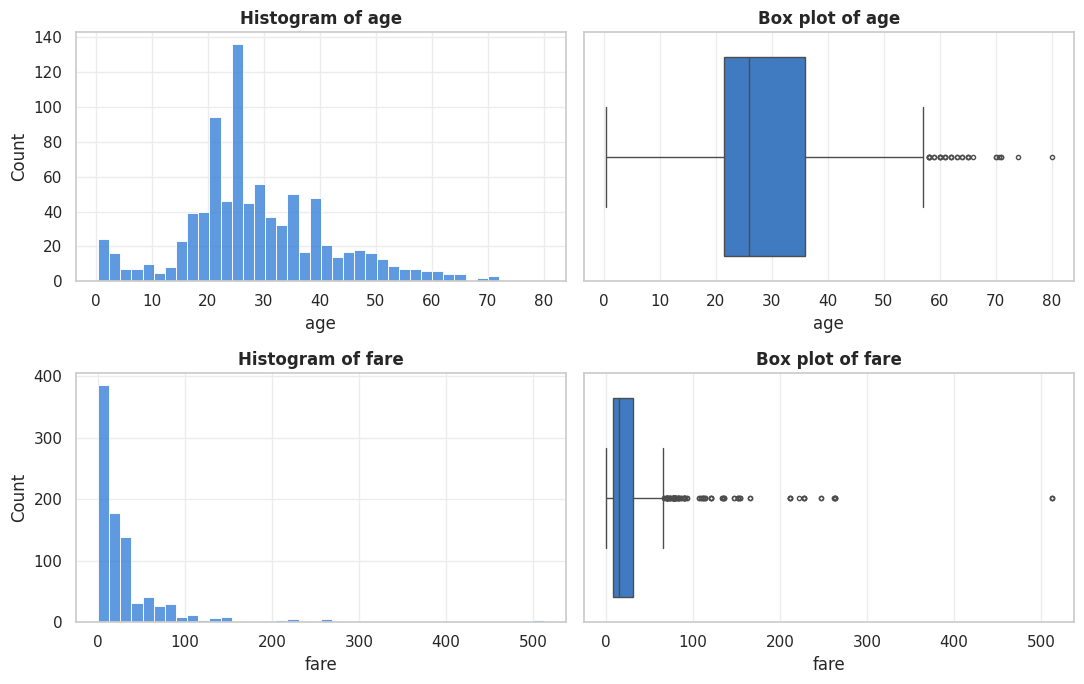

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for row, col in enumerate(["age", "fare"]):
    sns.histplot(df[col], bins=40, color=SURVIVED, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram of {col}")
    sns.boxplot(x=df[col], color=SURVIVED, ax=axes[row, 1], fliersize=3)
    axes[row, 1].set_title(f"Box plot of {col}")
save(fig, "01_univariate_age_fare.png")

In [10]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((s < low) | (s > high)).sum())
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower fence": low, "upper fence": high, "outliers": n}

outliers = pd.DataFrame({
    "age (cleaned)": iqr_outliers(df["age"]),
    "age (raw, non-missing only)": iqr_outliers(df_raw["age"].dropna()),
    "fare (cleaned)": iqr_outliers(df["fare"]),
}).T.round(2)
outliers

,Q1,Q3,IQR,lower fence,upper fence,outliers
age (cleaned),21.50,36.0,14.50,-0.25,57.75,32.0
"age (raw, non-missing only)",20.12,38.0,17.88,-6.69,64.81,11.0
fare (cleaned),7.90,31.0,23.10,-26.76,65.66,114.0


In [11]:
fare_stats = pd.Series({
    "mean": df["fare"].mean(),
    "median": df["fare"].median(),
    "mode": df["fare"].mode().iloc[0],
    "skewness": df["fare"].skew(),
}).round(3)
fare_stats

mean        32.097
median      14.454
mode         8.050
skewness     4.801
dtype: float64

**Outliers (IQR rule).** `age` has 32 outliers, all passengers older than about 58 (the upper fence is 57.75). On the raw data, before the missing ages were filled in, it was only 11: filling 177 missing ages with medians packs the middle of the data closer together, so more old passengers land outside the range. `fare` has 114 outliers, meaning every fare above £65.66, mostly expensive 1st-class tickets, with the highest at £512. I kept all of them because they are real passengers, not data errors.

**Skewness of `fare`.** `fare` is right-skewed. The mean is 32.10, the median is 14.45 and the mode is 8.05. Since mean > median > mode, a few very large values are pulling the mean up, and the skewness value of 4.80 shows the skew is strong. This happens because most passengers paid cheap 3rd-class fares of around £8, while a few expensive tickets up to £512 stretch the tail to the right. The histogram shows the same thing: a tall bar near £0–15 and then a long thin tail.

## Task 4 — Bivariate analysis

In [12]:
def rate(mask):
    # survival rate for the rows selected by a boolean mask
    return round(df.loc[mask, "survived"].mean() * 100, 2)

male, female = df["sex"] == "male", df["sex"] == "female"
c1, c2, c3 = df["pclass"] == 1, df["pclass"] == 2, df["pclass"] == 3

# (a) by sex
by_sex = pd.Series({"female": rate(female), "male": rate(male)}, name="survival %")
# (b) by class
by_class = pd.Series({"1st": rate(c1), "2nd": rate(c2), "3rd": rate(c3)}, name="survival %")
# (c) sex AND class together, combining masks with &
by_both = pd.DataFrame({
    "1st": [rate(female & c1), rate(male & c1)],
    "2nd": [rate(female & c2), rate(male & c2)],
    "3rd": [rate(female & c3), rate(male & c3)],
}, index=["female", "male"])

print("(a) by sex\n", by_sex.to_string(), "\n")
print("(b) by pclass\n", by_class.to_string(), "\n")
print("(c) by sex & pclass (survival %)\n", by_both.to_string(), "\n")

# | example: women OR children (under 16) vs adult men
women_or_children = female | (df["age"] < 16)
print("women OR children (age < 16):", rate(women_or_children), "%")
print("adult men (male & age >= 16):", rate(male & (df["age"] >= 16)), "%")

(a) by sex
 female    74.04
male      18.89 

(b) by pclass
 1st    62.62
2nd    47.28
3rd    24.24 

(c) by sex & pclass (survival %)
           1st    2nd    3rd
female  96.74  92.11  50.00
male    36.89  15.74  13.54 

women OR children (age < 16): 71.59 %
adult men (male & age >= 16): 16.39 %


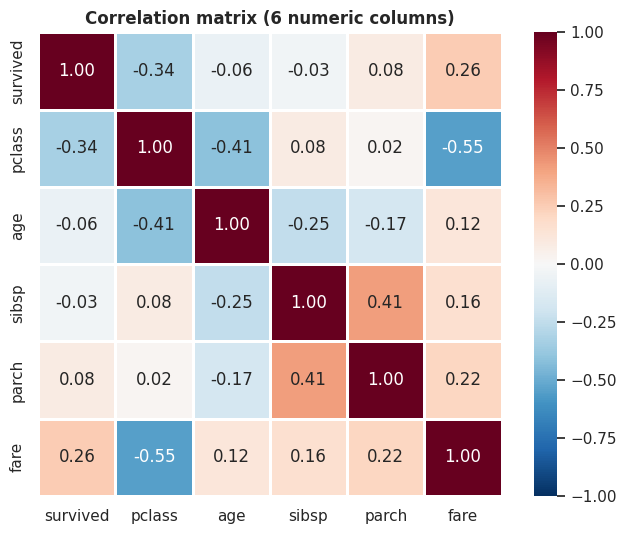

corr  abs_corr
pclass   fare   -0.548     0.548
sibsp    parch   0.415     0.415
pclass   age    -0.411     0.411
survived pclass -0.336     0.336
         fare    0.255     0.255

In [13]:
CORR_COLS = ["survived", "pclass", "age", "sibsp", "parch", "fare"]   # adult_male and alone excluded
corr = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, linecolor="white", ax=ax)
ax.set_title("Correlation matrix (6 numeric columns)")
save(fig, "02_correlation_heatmap.png")

# Rank every off-diagonal pair by absolute correlation
pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
             .stack().rename("corr").to_frame())
pairs["abs_corr"] = pairs["corr"].abs()
pairs.sort_values("abs_corr", ascending=False).head(5).round(3)

**The two strongest correlations.** Of all the pairs, the two strongest are:

1. **`pclass` – `fare`: −0.55.** This is the strongest pair. A higher class number (3rd class) goes with a lower fare, which makes sense because you pay more for 1st class. For a model, it also means these two columns carry overlapping information.
2. **`sibsp` – `parch`: +0.41.** People with siblings or a spouse aboard also tend to have parents or children aboard, because families travel together. So both columns really measure family size.

## Task 5 — Multivariate data story: who survived, and why?

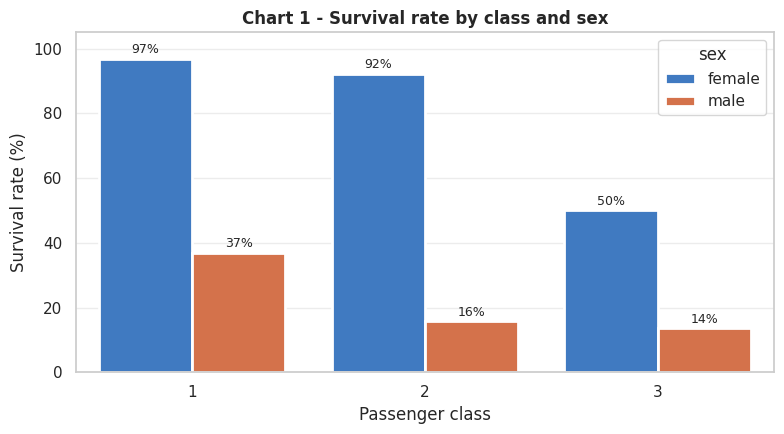

In [14]:
# Chart 1: survival rate by class, split by sex
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = df.groupby(["pclass", "sex"])["survived"].mean().mul(100).reset_index()
sns.barplot(data=plot_df, x="pclass", y="survived", hue="sex",
            palette={"female": SURVIVED, "male": DIED}, ax=ax, edgecolor="white", linewidth=2)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", padding=2, fontsize=9)
ax.set(xlabel="Passenger class", ylabel="Survival rate (%)", ylim=(0, 105),
       title="Chart 1 - Survival rate by class and sex")
save(fig, "03_story_class_sex.png")

**Interpretation.** Sex matters most: in every class, women survived far more often than men (97% vs 37% in 1st class). Class matters too, because survival drops from 1st to 3rd class for both women and men. "Women and children first" was followed, but even a woman in 3rd class had only a 50/50 chance.

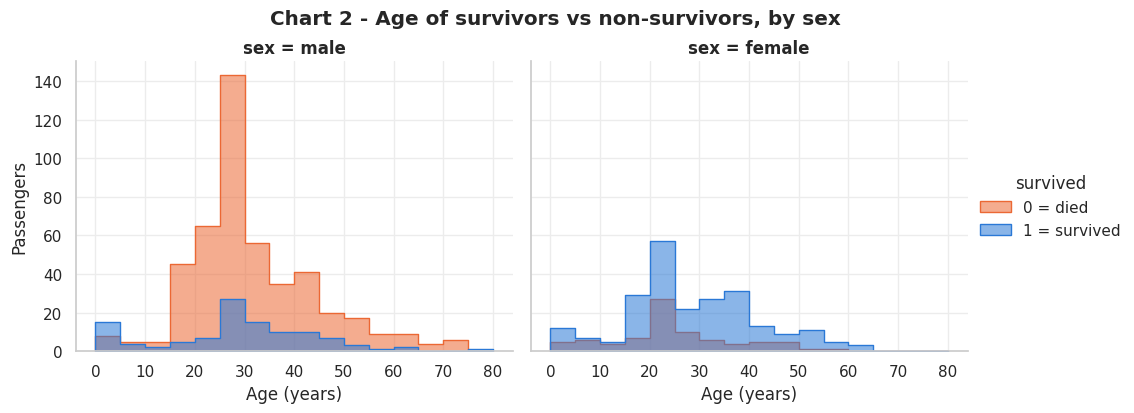

Survival % by age band and sex:
sex    female  male
age                
0-12     59.4  56.8
13-18    75.0   8.8
19-40    75.6  16.6
41-60    75.6  19.3
60+     100.0  10.5


In [15]:
# Chart 2: age distribution of survivors vs non-survivors, per sex
g = sns.FacetGrid(df, col="sex", hue="survived", palette=OUTCOME_COLORS, height=4, aspect=1.25)
g.map(sns.histplot, "age", bins=np.arange(0, 85, 5), alpha=0.55, element="step")
g.add_legend(title="survived", labels=["0 = died", "1 = survived"])
g.set_axis_labels("Age (years)", "Passengers")
g.figure.suptitle("Chart 2 - Age of survivors vs non-survivors, by sex", y=1.03, fontweight="bold")
g.savefig(CHARTS / "04_story_age_sex.png", dpi=120, bbox_inches="tight")
plt.show()

age_band = pd.cut(df["age"], [0, 12, 18, 40, 60, 100], labels=["0-12", "13-18", "19-40", "41-60", "60+"])
print("Survival % by age band and sex:")
print((df.groupby([age_band, "sex"], observed=True)["survived"].mean() * 100).round(1).unstack())

**Interpretation.** At almost every age, more men died than survived. The exception is young boys: boys aged 12 and under survived at 57%, while every other male age group survived at only 9–19%. For women it is the opposite, and more survived than died at almost every age. So age mainly matters for males, where being a child was nearly as protective as being female.

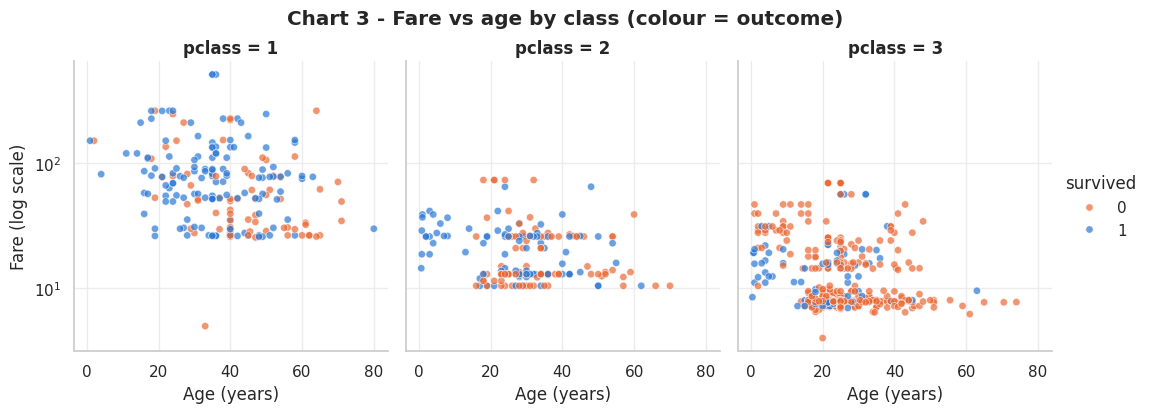

Median fare by class and outcome:
survived      0      1
pclass                
1         44.75  77.34
2         13.00  21.00
3          8.05   8.52


In [16]:
# Chart 3: fare vs age, coloured by outcome, one panel per class
g = sns.relplot(data=df, x="age", y="fare", hue="survived", col="pclass", palette=OUTCOME_COLORS,
                alpha=0.7, s=28, height=4, aspect=0.9, edgecolor="white", linewidth=0.5)
g.set(yscale="log")
g.set_axis_labels("Age (years)", "Fare (log scale)")
g.figure.suptitle("Chart 3 - Fare vs age by class (colour = outcome)", y=1.03, fontweight="bold")
g.savefig(CHARTS / "05_story_fare_age_class.png", dpi=120, bbox_inches="tight")
plt.show()

print("Median fare by class and outcome:")
print(df.groupby(["pclass", "survived"])["fare"].median().unstack().round(2))

**Interpretation.** 1st class is mostly blue (survived) dots, and survivors there also paid more than those who died (median fare £77 vs £45). 3rd class is a dense cluster of orange (died) dots at cheap fares of about £7–8, and fare barely separates who lived and who died (median £8.52 vs £8.05). So money helped mainly by buying a better class. Within 1st and 2nd class a higher fare meant better odds, but in 3rd class almost everyone paid the same low price.

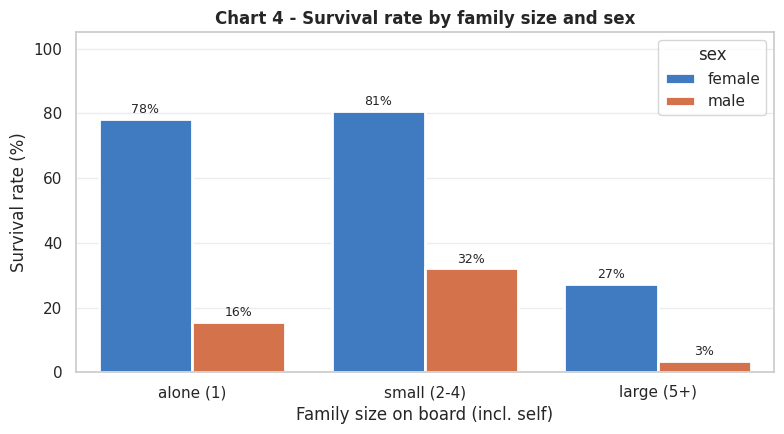

family_group    sex  survival %  passengers
   alone (1) female        78.2         124
   alone (1)   male        15.6         411
 small (2-4) female        80.6         155
 small (2-4)   male        32.1         137
  large (5+) female        27.3          33
  large (5+)   male         3.4          29


In [17]:
# Chart 4: family size vs survival rate, by sex
df_fam = df.assign(family_size=df["sibsp"] + df["parch"] + 1)
df_fam["family_group"] = pd.cut(df_fam["family_size"], [0, 1, 4, 20], labels=["alone (1)", "small (2-4)", "large (5+)"])
fam = df_fam.groupby(["family_group", "sex"], observed=True)["survived"].agg(["mean", "size"]).reset_index()
fam["mean"] *= 100

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=fam, x="family_group", y="mean", hue="sex",
            palette={"female": SURVIVED, "male": DIED}, ax=ax, edgecolor="white", linewidth=2)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.0f%%", padding=2, fontsize=9)
ax.set(xlabel="Family size on board (incl. self)", ylabel="Survival rate (%)", ylim=(0, 105),
       title="Chart 4 - Survival rate by family size and sex")
save(fig, "06_story_family_size.png")
print(fam.rename(columns={"mean": "survival %", "size": "passengers"}).round(1).to_string(index=False))

**Interpretation.** A small family (2–4 people) was the best position: men in small families survived at double the rate of men travelling alone (32% vs 16%). Large families of 5+ did very badly for both sexes (27% of women, 3% of men), because they were mostly in 3rd class and would have found it hard to stay together and reach the lifeboats. So survival goes up, then down, as family size grows. That's why `sibsp` and `parch` showed almost no correlation with `survived` in the heatmap: correlation only catches straight-line patterns.

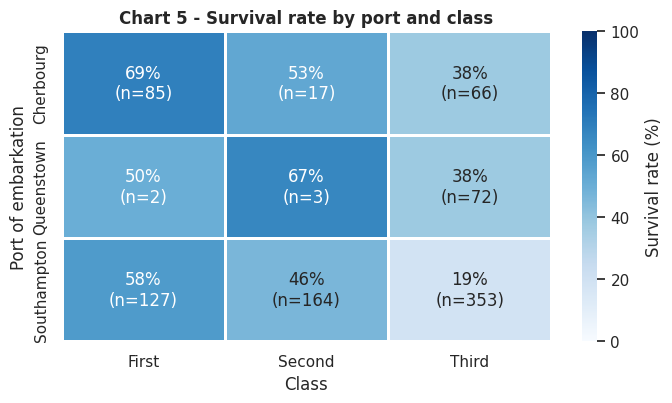

In [18]:
# Chart 5: survival heatmap of class x port of embarkation
pivot = df.pivot_table(index="embark_town", columns="class", values="survived", aggfunc="mean", observed=True) * 100
counts = df.pivot_table(index="embark_town", columns="class", values="survived", aggfunc="size", observed=True)
labels = pivot.round(0).astype(int).astype(str) + "%\n(n=" + counts.astype(str) + ")"

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.heatmap(pivot, annot=labels, fmt="", cmap="Blues", vmin=0, vmax=100, linewidths=2,
            linecolor="white", cbar_kws={"label": "Survival rate (%)"}, ax=ax)
ax.set(xlabel="Class", ylabel="Port of embarkation", title="Chart 5 - Survival rate by port and class")
save(fig, "07_story_port_class.png")

**Interpretation.** Cherbourg passengers survived more often than Southampton passengers in every class (69% vs 58% in 1st class). Southampton's 3rd class was the worst group: only 19% of 353 passengers survived, and it was also the biggest group on the ship. The port itself didn't cause survival; Cherbourg simply had more wealthy 1st-class passengers, while Southampton had most of the 3rd-class men. Queenstown's 1st and 2nd class boxes contain only 2–3 people each, so those percentages aren't reliable.

### The story in one paragraph

Survival was decided mostly by who you were (sex and age) and where you were (class). Women survived at 74% vs 19% for men, and children, especially boys, were the only group of males with good odds. Class then set the limit on top of that: almost all 1st- and 2nd-class women survived, while 3rd-class passengers died in the greatest numbers, especially Southampton's large 3rd-class group and large families. Fare and port look important, but mostly because they stand in for class, so `sex`, `pclass` and `age` should be the strongest features for the model in notebook 02.

## Task 6 — Exploratory z-score standardization of `age` and `fare`

In [19]:
z = df[["age", "fare"]].copy()
for col in ["age", "fare"]:
    z[col] = (df[col] - df[col].mean()) / df[col].std()   # z = (x - mean) / std

summary = pd.DataFrame({
    "mean before": df[["age", "fare"]].mean(),
    "std before": df[["age", "fare"]].std(),
    "mean after": z.mean(),
    "std after": z.std(),
}).round(4)
summary

,mean before,std before,mean after,std after
age,29.0654,13.2702,0.0,1.0
fare,32.0967,49.6975,0.0,1.0


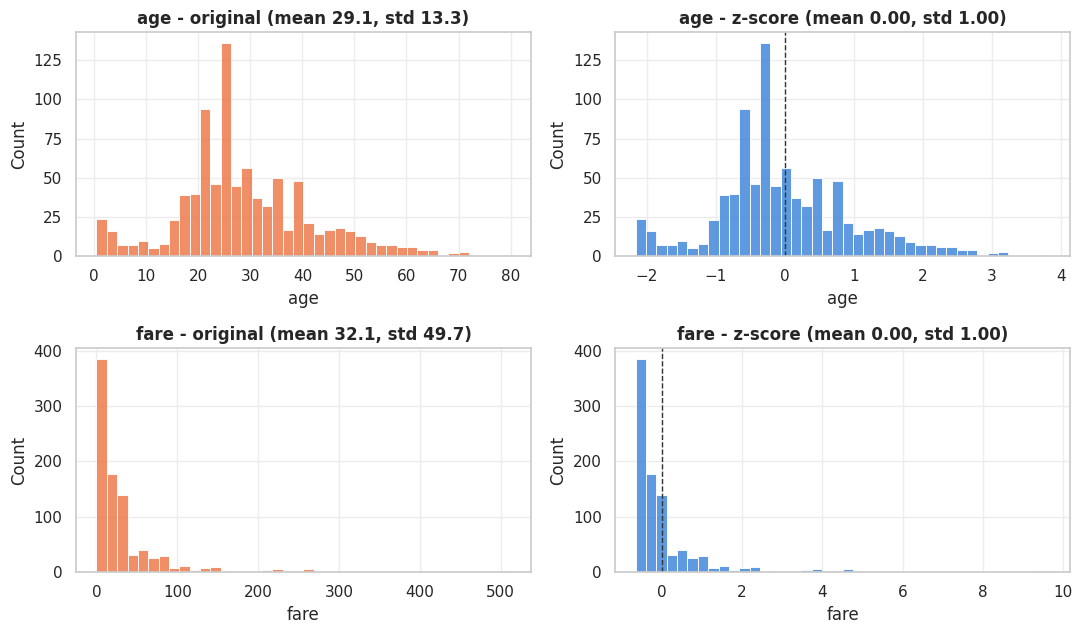

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6.5))
for i, col in enumerate(["age", "fare"]):
    sns.histplot(df[col], bins=40, color=DIED, ax=axes[i, 0])
    axes[i, 0].set_title(f"{col} - original (mean {df[col].mean():.1f}, std {df[col].std():.1f})")
    sns.histplot(z[col], bins=40, color=SURVIVED, ax=axes[i, 1])
    axes[i, 1].axvline(0, color="#333333", lw=1, ls="--")
    axes[i, 1].set_title(f"{col} - z-score (mean {z[col].mean():.2f}, std {z[col].std():.2f})")
save(fig, "08_zscore_before_after.png")

**Result.** We standardized `age` and `fare` with z = (x − mean) / std. After that, both columns have mean 0 and standard deviation 1, which shows the formula worked. Before, age had mean 29.07 and std 13.27, and fare had mean 32.10 and std 49.70. The shape doesn't change: fare is still just as right-skewed after scaling, because standardizing only shifts and rescales the numbers and doesn't remove skew or outliers.

This was only a check during EDA. The model in notebook 02 doesn't use these z-scores. It fits its own scaler on the training data only, so no test information leaks in.